Learning Rate: 0.01 Final Loss: 0.24057125688557163
Learning Rate: 0.05 Final Loss: 0.012541423741468993
Learning Rate: 0.1 Final Loss: 0.002546132340364792
Learning Rate: 0.5 Final Loss: 0.0002932111088818049
Learning Rate: 1.0 Final Loss: 0.0001352134372827767


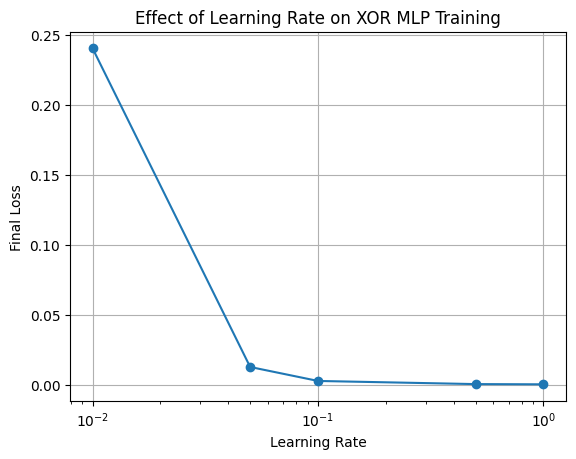

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

X = np.array([
[0,0],
[0,1],
[1,0],
[1,1]
])

y = np.array([[0],[1],[1],[0]])

learning_rates = [0.01,0.05,0.1,0.5,1.0]
final_losses = []

epochs = 10000

for lr in learning_rates:

    np.random.seed(42)

    W1 = np.random.rand(2,2)
    b1 = np.random.rand(1,2)

    W2 = np.random.rand(2,1)
    b2 = np.random.rand(1,1)

    for epoch in range(epochs):

        hidden_input = np.dot(X,W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output,W2) + b2
        y_pred = sigmoid(final_input)

        error = y - y_pred
        loss = np.mean(error**2)

        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output,axis=0,keepdims=True) * lr

        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden,axis=0,keepdims=True) * lr

    final_losses.append(loss)
    print("Learning Rate:",lr,"Final Loss:",loss)

plt.figure()
plt.plot(learning_rates,final_losses,marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

In [4]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]
for lr in learning_rates:
    model = Perceptron(eta0=lr, max_iter=1000, random_state=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Learning Rate:", lr, " Accuracy:", accuracy)

Learning Rate: 0.0001  Accuracy: 0.6444444444444445
Learning Rate: 0.001  Accuracy: 0.6222222222222222
Learning Rate: 0.01  Accuracy: 0.8
Learning Rate: 0.1  Accuracy: 0.8
Learning Rate: 1  Accuracy: 0.8


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (54000, 784)
Testing shape: (6000, 784)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.9996666666666667
Testing set score: 0.974
Predicted value: 6
Actual value: 6


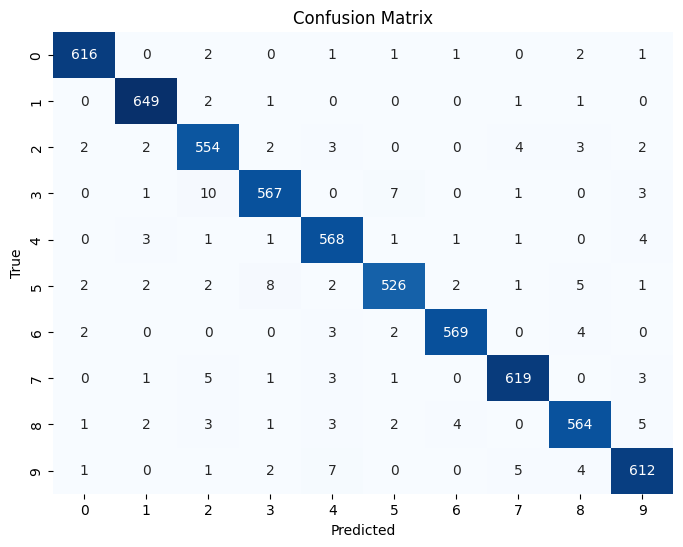

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794427
Iteration 5, loss = 0.42552618
Iteration 6, loss = 0.42483506
Iteration 7, loss = 0.43145128
Iteration 8, loss = 0.42965931
Iteration 9, loss = 0.48689868
Iteration 10, loss = 0.43131150
Iteration 11, loss = 0.44657347
Iteration 12, loss = 0.44554835
Iteration 13, loss = 0.43811670
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8982037037037037
Testing set score (MLP2): 0.8838333333333334


In [6]:
from tensorflow.keras.datasets import mnist
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

X_train_full = X_train_full / 255.0
X_test_full = X_test_full / 255.0

X_train_full = X_train_full.reshape(-1, 784)
X_test_full = X_test_full.reshape(-1, 784)

X_train, X_test, y_train, y_test = train_test_split( X_train_full,y_train_full,test_size=0.10,random_state=42)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

mlp = MLPClassifier(hidden_layer_sizes=(50,),max_iter=50,verbose=0,random_state=1)
mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

index = 346
test_digit = X_test[index].reshape(1, 784)
prediction = mlp.predict(test_digit)[0]
print("Predicted value:", prediction)
print("Actual value:", y_test[index])
preds = mlp.predict(X_test)
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mlp2 = MLPClassifier(hidden_layer_sizes=(50,),max_iter=50,verbose=1,random_state=1,learning_rate_init=0.1)
mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))

In [9]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

learning_rates = [0.0001, 0.001, 0.01, 0.1]
iterations = [100, 200, 500]

for lr in learning_rates:
    for it in iterations:
        model = MLPClassifier(hidden_layer_sizes=(10,10),learning_rate_init=lr,max_iter=it,random_state=1)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Learning Rate:", lr,"Iterations:", it,"Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001 Iterations: 100 Accuracy: 0.28888888888888886
Learning Rate: 0.0001 Iterations: 200 Accuracy: 0.28888888888888886


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001 Iterations: 500 Accuracy: 0.28888888888888886
Learning Rate: 0.001 Iterations: 100 Accuracy: 0.5111111111111111


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.001 Iterations: 200 Accuracy: 0.7777777777777778


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.001 Iterations: 500 Accuracy: 0.9555555555555556
Learning Rate: 0.01 Iterations: 100 Accuracy: 0.9777777777777777
Learning Rate: 0.01 Iterations: 200 Accuracy: 0.9777777777777777
Learning Rate: 0.01 Iterations: 500 Accuracy: 0.9777777777777777
Learning Rate: 0.1 Iterations: 100 Accuracy: 1.0
Learning Rate: 0.1 Iterations: 200 Accuracy: 1.0
Learning Rate: 0.1 Iterations: 500 Accuracy: 1.0


In [10]:
from tensorflow.keras.datasets import mnist
from sklearn.neural_network import MLPClassifier
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=50)
mlp.fit(X_train, y_train)

print("Training Accuracy:", mlp.score(X_train, y_train))
print("Testing Accuracy:", mlp.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training Accuracy: 0.9994333333333333
Testing Accuracy: 0.9728


In [5]:
import numpy as np

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

np.random.seed(1)
W1 = np.random.rand(2,2)
b1 = np.random.rand(1,2)
W2 = np.random.rand(2,1)
b2 = np.random.rand(1,1)

lr = 0.5
epochs = 10000

for epoch in range(epochs):

    hidden_input = np.dot(X,W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output,W2) + b2
    y_pred = sigmoid(final_input)

    error = y - y_pred
    loss = np.mean(error**2)

    d_output = error * sigmoid_derivative(y_pred)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    W2 += hidden_output.T.dot(d_output) * lr
    b2 += np.sum(d_output,axis=0,keepdims=True) * lr

    W1 += X.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden,axis=0,keepdims=True) * lr

    if epoch % 1000 == 0:
        print("Epoch:",epoch,"Loss:",loss)

print("\nPredictions")
print(y_pred)

Epoch: 0 Loss: 0.28014363590911784
Epoch: 1000 Loss: 0.11558328306843396
Epoch: 2000 Loss: 0.0037882256157506697
Epoch: 3000 Loss: 0.0016500724785991235
Epoch: 4000 Loss: 0.0010340080889508002
Epoch: 5000 Loss: 0.0007473297341888478
Epoch: 6000 Loss: 0.0005829256562755849
Epoch: 7000 Loss: 0.00047676539562144097
Epoch: 8000 Loss: 0.0004027435073518473
Epoch: 9000 Loss: 0.00034827599558810625

Predictions
[[0.01931569]
 [0.98331818]
 [0.9833515 ]
 [0.01725879]]
